## 1.1 Preprocesamiento

En esta sección se preparan los datos para aplicar clustering.  
Se eliminan variables que no aportan al agrupamiento (identificadores, texto y variables categóricas no transformadas), se seleccionan variables numéricas relevantes y se estandarizan para que todas tengan la misma escala.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# Cargar dataset
df = pd.read_csv("movies_2026.csv", encoding="latin1")

# Vista general
print("Dimensiones del dataset:", df.shape)
display(df.head())
print("\nColumnas:")
print(df.columns.tolist())

Dimensiones del dataset: (19883, 28)


,id,budget,genres,homePage,productionCompany,productionCompanyCountry,productionCountry,revenue,runtime,video,...,releaseDate,voteAvg,voteCount,genresAmount,productionCoAmount,productionCountriesAmount,actorsAmount,castWomenAmount,castMenAmount,releaseYear
0,1627085,0.0,Drama|Crime,NaN,NaN,NaN,NaN,0.0,95,False,...,2026-02-01,0.0,0,2,0,0,8,2.0,5.0,2026.0
1,1626914,0.0,Animation,NaN,NaN,NaN,NaN,0.0,3,False,...,2026-02-01,0.0,0,1,0,0,4,0.0,0.0,2026.0
2,1626898,0.0,Animation,NaN,NaN,NaN,NaN,0.0,2,False,...,2026-02-01,0.0,0,1,0,0,3,0.0,0.0,2026.0
3,1626808,0.0,Thriller|Mystery|Documentary,NaN,NaN,NaN,NaN,0.0,5,False,...,2026-02-01,0.0,0,3,0,0,7,0.0,0.0,2026.0
4,1626678,0.0,Animation,NaN,NaN,NaN,NaN,0.0,12,False,...,2026-02-01,0.0,0,1,0,0,3,0.0,0.0,2026.0



Columnas:
['id', 'budget', 'genres', 'homePage', 'productionCompany', 'productionCompanyCountry', 'productionCountry', 'revenue', 'runtime', 'video', 'director', 'actors', 'actorsPopularity', 'actorsCharacter', 'originalTitle', 'title', 'originalLanguage', 'popularity', 'releaseDate', 'voteAvg', 'voteCount', 'genresAmount', 'productionCoAmount', 'productionCountriesAmount', 'actorsAmount', 'castWomenAmount', 'castMenAmount', 'releaseYear']


### Variables eliminadas y justificación

Se eliminan variables de tipo identificador, texto o categóricas no transformadas, ya que no son adecuadas para calcular distancias directamente entre observaciones.

In [17]:
# Variables que se eliminan
columns_to_drop = [
    'id',
    'genres',
    'homePage',
    'productionCompany',
    'productionCompanyCountry',
    'productionCountry',
    'director',
    'actors',
    'actorsPopularity',
    'actorsCharacter',
    'originalTitle',
    'title',
    'originalLanguage',
    'releaseDate',
    'video'
]

# Crear copia sin esas columnas
df_clean = df.drop(columns=columns_to_drop)

print("Columnas restantes después de eliminar:")
print(df_clean.columns.tolist())
print("\nDimensiones:", df_clean.shape)

Columnas restantes después de eliminar:
['budget', 'revenue', 'runtime', 'popularity', 'voteAvg', 'voteCount', 'genresAmount', 'productionCoAmount', 'productionCountriesAmount', 'actorsAmount', 'castWomenAmount', 'castMenAmount', 'releaseYear']

Dimensiones: (19883, 13)


### Variables seleccionadas para clustering

Se usan variables numéricas relacionadas con presupuesto, ingresos, duración, popularidad, votos, cantidad de géneros, producción y reparto, ya que permiten comparar películas mediante distancias.

In [18]:
# Variables numéricas que sí se usarán
numeric_features = [
    'budget',
    'revenue',
    'runtime',
    'popularity',
    'voteAvg',
    'voteCount',
    'genresAmount',
    'productionCoAmount',
    'productionCountriesAmount',
    'actorsAmount',
    'castWomenAmount',
    'castMenAmount',
    'releaseYear'
]

# Subconjunto final para clustering
df_clust = df_clean[numeric_features].copy()

# Revisar nulos
print("Nulos por columna:")
print(df_clust.isnull().sum())

# Eliminar filas con nulos
df_clust = df_clust.dropna()

print("\nDimensiones después de quitar nulos:", df_clust.shape)
display(df_clust.head())

Nulos por columna:
budget                         0
revenue                        0
runtime                        0
popularity                     0
voteAvg                        0
voteCount                      0
genresAmount                   0
productionCoAmount             0
productionCountriesAmount      0
actorsAmount                   0
castWomenAmount               37
castMenAmount                162
releaseYear                    2
dtype: int64

Dimensiones después de quitar nulos: (19719, 13)


,budget,revenue,runtime,popularity,voteAvg,voteCount,genresAmount,productionCoAmount,productionCountriesAmount,actorsAmount,castWomenAmount,castMenAmount,releaseYear
0,0.0,0.0,95,0.0357,0.0,0,2,0,0,8,2.0,5.0,2026.0
1,0.0,0.0,3,0.0357,0.0,0,1,0,0,4,0.0,0.0,2026.0
2,0.0,0.0,2,0.0214,0.0,0,1,0,0,3,0.0,0.0,2026.0
3,0.0,0.0,5,0.0429,0.0,0,3,0,0,7,0.0,0.0,2026.0
4,0.0,0.0,12,0.0379,0.0,0,1,0,0,3,0.0,0.0,2026.0


In [19]:
# Escalado 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clust)

# Convertir a DataFrame para visualizar mejor
X_scaled_df = pd.DataFrame(X_scaled, columns=numeric_features)

print("Datos estandarizados (primeras filas):")
display(X_scaled_df.head())

Datos estandarizados (primeras filas):


,budget,revenue,runtime,popularity,voteAvg,voteCount,genresAmount,productionCoAmount,productionCountriesAmount,actorsAmount,castWomenAmount,castMenAmount,releaseYear
0,-0.340683,-0.260423,0.575777,-0.166663,-1.123027,-0.350255,0.039986,-0.9052,-0.546851,-0.383349,-0.335978,-0.115355,0.711111
1,-0.340683,-0.260423,-1.260582,-0.166663,-1.123027,-0.350255,-0.760497,-0.9052,-0.546851,-0.581927,-0.693708,-0.115425,0.711111
2,-0.340683,-0.260423,-1.280542,-0.166754,-1.123027,-0.350255,-0.760497,-0.9052,-0.546851,-0.631571,-0.693708,-0.115425,0.711111
3,-0.340683,-0.260423,-1.220661,-0.166617,-1.123027,-0.350255,0.840468,-0.9052,-0.546851,-0.432993,-0.693708,-0.115425,0.711111
4,-0.340683,-0.260423,-1.080938,-0.166649,-1.123027,-0.350255,-0.760497,-0.9052,-0.546851,-0.631571,-0.693708,-0.115425,0.711111


Se eliminaron variables de texto, identificadores y categóricas no transformadas porque no aportan a la comparación numérica entre películas.  
Luego se seleccionaron variables numéricas relevantes para el análisis y se estandarizaron para evitar que variables con valores grandes (como budget o revenue) dominen el agrupamiento.

## 1.2 Tendencia al agrupamiento

Antes de aplicar clustering, se evalúa si los datos tienen una estructura agrupable.  
Para ello se usa el estadístico de Hopkins y una visualización tipo VAT.

In [20]:
from sklearn.neighbors import NearestNeighbors
from random import sample
from numpy.random import uniform

def hopkins_stat(X):
    X = np.array(X)
    n, d = X.shape
    m = max(10, int(0.1 * n))  

    nbrs = NearestNeighbors(n_neighbors=2).fit(X)

    # Puntos aleatorios dentro del rango de los datos
    rand_X = uniform(np.min(X, axis=0), np.max(X, axis=0), (m, d))

    u_dist = []
    w_dist = []

    random_indices = sample(range(n), m)

    for j in range(m):
        # Distancia de punto aleatorio al vecino más cercano real
        u = nbrs.kneighbors([rand_X[j]], n_neighbors=2, return_distance=True)[0][0][0]
        u_dist.append(u)

        # Distancia de punto real a su vecino real más cercano (ignorando sí mismo)
        w = nbrs.kneighbors([X[random_indices[j]]], n_neighbors=2, return_distance=True)[0][0][1]
        w_dist.append(w)

    H = sum(u_dist) / (sum(u_dist) + sum(w_dist))
    return H

hopkins_value = hopkins_stat(X_scaled)
print(f"Hopkins: {hopkins_value:.4f}")

Hopkins: 0.9864


### Interpretación de Hopkins

- Valor cercano a 0.5: datos con estructura aleatoria
- Valor mayor a 0.7: buena tendencia al agrupamiento
- Valor cercano a 1: fuerte tendencia al agrupamiento


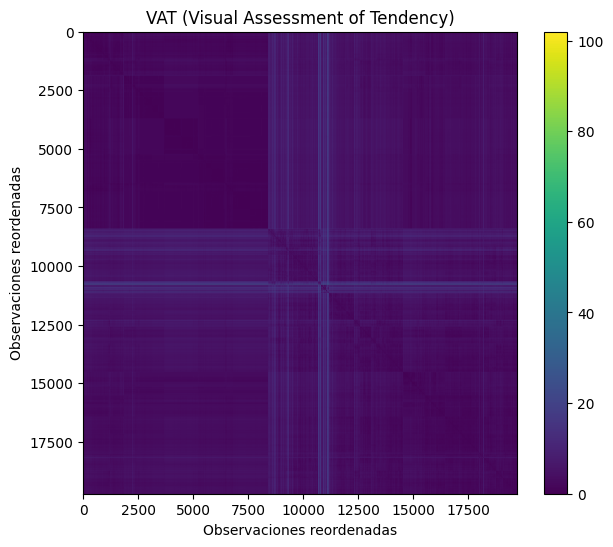

In [21]:
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, leaves_list

# Matriz de distancias entre observaciones
D = squareform(pdist(X_scaled, metric='euclidean'))

# Reordenamiento jerárquico para aproximar VAT
Z = linkage(X_scaled, method='ward')
order = leaves_list(Z)

D_reordered = D[order][:, order]

plt.figure(figsize=(7, 6))
plt.imshow(D_reordered, aspect='auto')
plt.title("VAT (Visual Assessment of Tendency)")
plt.xlabel("Observaciones reordenadas")
plt.ylabel("Observaciones reordenadas")
plt.colorbar()
plt.show()

### Interpretación del VAT

En el gráfico VAT se observan bloques o zonas más oscuras, lo que sugiere la presencia de grupos naturales en los datos.  
Si la imagen se ve totalmente uniforme, la tendencia al agrupamiento sería débil.

## 1.3 Número de clústeres

Se utiliza el método del codo para estimar el número adecuado de clústeres.  
Este método grafica la inercia para distintos valores de k y permite identificar un punto de inflexión.

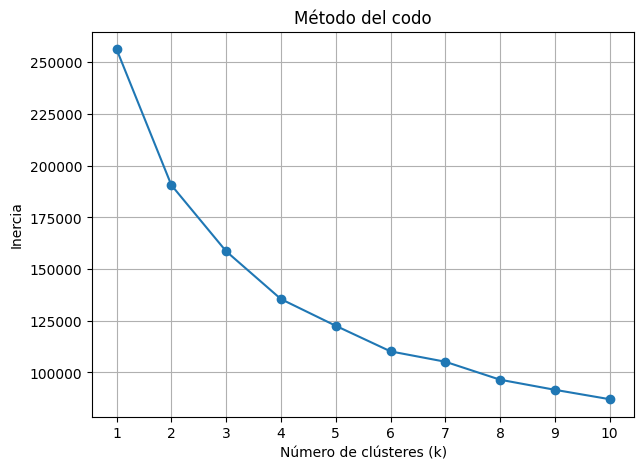

In [22]:
from sklearn.cluster import KMeans

inertia = []
K_values = range(1, 11)

for k in K_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(K_values, inertia, marker='o')
plt.xticks(K_values)
plt.xlabel("Número de clústeres (k)")
plt.ylabel("Inercia")
plt.title("Método del codo")
plt.grid(True)
plt.show()

### Justificación del número de clústeres

En la gráfica del codo se identifica un punto de inflexión en **k = X** (reemplazar con el valor observado).  
A partir de ese valor, la reducción de inercia es menor, por lo que se considera una cantidad adecuada de clústeres para el análisis.

pd.DataFrame({
    "k": list(K_values),
    "inercia": inertia
})

k-means

In [23]:
from sklearn.cluster import KMeans

k = 4

kmeans = KMeans(n_clusters=k, random_state=42)
clusters_kmeans = kmeans.fit_predict(X_scaled)

df_clust['cluster_kmeans'] = clusters_kmeans

clustering jerarquico 

In [24]:
from scipy.cluster.hierarchy import linkage, fcluster

Z = linkage(X_scaled, method='ward')

clusters_jer = fcluster(Z, k, criterion='maxclust')

df_clust['cluster_jerarquico'] = clusters_jer

Comparación básica de tamaños de clusters

In [ ]:
print("KMeans")
print(df_clust['cluster_kmeans'].value_counts())

print("\nJerárquico")
print(df_clust['cluster_jerarquico'].value_counts())

KMeans
cluster_kmeans
2    8656
0    6710
1    3856
3     497
Name: count, dtype: int64

Jerárquico
cluster_jerarquico
4    8585
1    8393
2    2396
3     345
Name: count, dtype: int64


Calidad del agrupamiento

Silhouette para K-Means

In [ ]:
from sklearn.metrics import silhouette_score

sil_kmeans = silhouette_score(X_scaled, clusters_kmeans)
print("Silhouette KMeans:", sil_kmeans)

Silhouette KMeans: 0.3197189698147048


Silhouette para Jerárquico

In [ ]:
sil_jer = silhouette_score(X_scaled, clusters_jer)
print("Silhouette Jerárquico:", sil_jer)

Silhouette Jerárquico: 0.3285882612809645


Gráfica comparativa

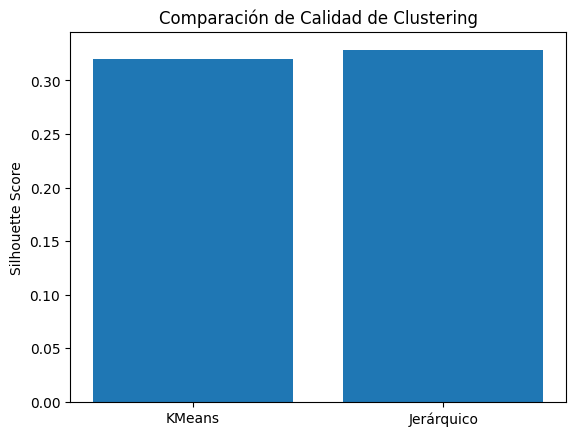

In [ ]:
plt.bar(['KMeans', 'Jerárquico'], [sil_kmeans, sil_jer])
plt.ylabel("Silhouette Score")
plt.title("Comparación de Calidad de Clustering")
plt.show()

Interpretación de los Grupos

Medidas de tendencia central

In [ ]:
df_clust.groupby('cluster_kmeans').mean()

,budget,revenue,runtime,popularity,voteAvg,voteCount,genresAmount,productionCoAmount,productionCountriesAmount,actorsAmount,castWomenAmount,castMenAmount,releaseYear,cluster_jerarquico
cluster_kmeans,,,,,,,,,,,,,,
0,2.468372e+06,4.679009e+06,89.023994,36.891875,6.430225,276.726677,2.400745,2.424441,1.760209,13.909985,3.978390,24101.776155,2015.525484,3.834277
1,2.719439e+07,6.920589e+07,110.485477,36.799680,6.629798,1808.845695,2.742998,3.848548,1.512189,40.636670,10.183351,35.024896,2001.133558,3.050052
2,5.355115e+03,1.484243e+03,25.400531,0.523389,0.361139,0.194085,1.174561,0.608364,0.666474,3.387015,0.449284,36.841266,2025.203212,1.164164
3,1.316976e+08,5.507711e+08,123.223340,244.592698,7.008491,9259.418511,3.219316,3.824950,1.498994,61.712274,13.334004,31.338028,2010.861167,2.000000


Variables categóricas

In [ ]:
pd.crosstab(df['originalLanguage'], df_clust['cluster_kmeans'])

cluster_kmeans,0,1,2,3
originalLanguage,,,,
ab,1,0,0,0
af,0,0,4,0
am,0,0,15,0
ar,17,0,89,0
as,0,0,2,0
...,...,...,...,...
vi,5,0,24,0
xh,0,0,1,0
xx,1,0,91,0
